<a href="https://colab.research.google.com/github/riddhi2309/Celebal_assignment/blob/main/Week5_Riddhi_Khandelwal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [ ]:
corpus = '''
NASA’s Parker Solar Probe completed its 28th close approach to the Sun on June 8, again matching its record distance of 3.8 million miles from the solar surface. The flyby allowed the spacecraft to continue its measurements of the solar wind and solar activity at their source, while adding to our understanding of how the Sun’s atmosphere changes throughout the solar cycle.

The spacecraft checked in with flight controllers at the Johns Hopkins Applied Physics Laboratory (APL) in Laurel, Maryland — where Parker Solar Probe was designed and built — on Thursday, transmitting a beacon tone that indicated its systems were operating normally. Zooming around the Sun on a trajectory that limited communications with Earth, Parker had been out of contact and operating autonomously for nine days around its closest approach, as planned.

During this solar encounter, which started June 3 and ends Saturday, June 13, Parker’s four scientific instrument packages gathered data from inside the Sun’s atmosphere, or corona. Parker will begin returning detailed spacecraft telemetry on June 14, with science data transmission set to run from Wednesday, June 17 to Tuesday, June 30.

Parker’s observations of the solar wind and solar events, such as coronal mass ejections and the aftermaths of flares, are critical to advancing humanity’s understanding of the Sun and the phenomena that drive high-energy space weather events that pose risks to astronauts, satellites, air travel, and even power grids on Earth. Understanding the fundamental physics of space weather enables more reliable prediction of astronaut safety during future deep-space missions to the Moon and Mars.

Parker also equaled its record-setting speed of 430,000 mph — a mark that, like Parker’s distance to the Sun, was set during a close approach on Dec. 24, 2024, and matched during five flybys since, most recently on March 11. Parker will continue matching these speed and distance records during future flybys.

Through all six close approaches, mission leads say, the spacecraft has remained in excellent condition. While Parker doesn’t have a temperature sensor on the front of its heat shield — known as the Thermal Protection System, or TPS — the team can estimate through models that the heat shield reaches temperatures of about 1,700 degrees Fahrenheit at closest approach.
“The heat shield material is incredibly light and fragile, but the thermal design, as well as the software that keeps the spacecraft pointing the TPS toward the Sun, have been outstanding,” said John Wirzburger, Parker Solar Probe mission systems engineer at APL. “It’s a real tribute to the team that designed, built, and operates Parker Solar Probe.”

Meanwhile, the team can measure the temperature of the barrier blanketing below the heat shield, and the actual spacecraft temperature has remained consistent on each pass.

“That temperature consistency is a major indicator of spacecraft health,” said Wirzburger. “It tells us the heat shield isn’t degrading. If it were cracking or weakening, we’d see temperatures drift upward as more heat leaked through.”

Parker launched in August 2018. At the time, the Sun was near the minimum of its 11-year activity cycle. In 2024, representatives from NASA, the National Oceanic and Atmospheric Administration (NOAA), and the international Solar Cycle Prediction Panel announced that the Sun had reached its solar maximum period. Parker’s 28 encounters with the Sun reflect this change over time, sampling the Sun’s atmosphere from quiet to very active periods. Parker Solar Probe will remain in this orbit around the Sun and continue making observations into the declining phase of solar activity.

The next steps for the mission in late 2026 and beyond are under NASA review.

Parker Solar Probe was developed as a part of NASA’s Living With a Star (LWS) program to explore aspects of the Sun-Earth system that directly affect life and society. The LWS program is managed by the agency’s Goddard Space Flight Center in Greenbelt, Maryland, for NASA’s Science Mission Directorate in Washington. Johns Hopkins APL manages Parker Solar Probe for NASA and designed, built, and now operates the mission.

Operations teams have confirmed NASA’s mission to “touch” the Sun survived its record-breaking closest approach to the solar surface on Dec. 24, 2024.

Breaking its previous record by flying just 3.8 million miles above the surface of the Sun, NASA’s Parker Solar Probe hurtled through the solar atmosphere at a blazing 430,000 miles per hour — faster than any human-made object has ever moved. A beacon tone received late on Dec. 26 confirmed the spacecraft had made it through the encounter safely and is operating normally.

This pass, the first of more to come at this distance, allows the spacecraft to conduct unrivaled scientific measurements with the potential to change our understanding of the Sun.

"Flying this close to the Sun is a historic moment in humanity’s first mission to a star,” said Nicky Fox, who leads the Science Mission Directorate at NASA Headquarters in Washington. “By studying the Sun up close, we can better understand its impacts throughout our solar system, including on the technology we use daily on Earth and in space, as well as learn about the workings of stars across the universe to aid in our search for habitable worlds beyond our home planet.”

Parker Solar Probe has spent the last six years setting up for this moment. Launched in 2018, the spacecraft used seven flybys of Venus to gravitationally direct it ever closer to the Sun. With its last Venus flyby on Nov. 6, 2024, the spacecraft reached its optimal orbit. This oval-shaped orbit brings the spacecraft an ideal distance from the Sun every three months — close enough to study our Sun’s mysterious processes but not too close to become overwhelmed by the Sun’s heat and damaging radiation. The spacecraft will remain in this orbit for the remainder of its primary mission.

“Parker Solar Probe is braving one of the most extreme environments in space and exceeding all expectations,” said Nour Rawafi, the project scientist for Parker Solar Probe at the Johns Hopkins Applied Physics Laboratory (APL), which designed, built, and operates the spacecraft from its campus in Laurel, Maryland. “This mission is ushering a new golden era of space exploration, bringing us closer than ever to unlocking the Sun’s deepest and most enduring mysteries.”

Close to the Sun, the spacecraft relies on a carbon foam shield to protect it from the extreme heat in the upper solar atmosphere called the corona, which can exceed 1 million degrees Fahrenheit. The shield was designed to reach temperatures of 2,600 degrees Fahrenheit — hot enough to melt steel — while keeping the instruments behind it shaded at a comfortable room temperature. In the hot but low-density corona, the spacecraft’s shield is expected to warm to 1,800 degrees Fahrenheit.

“It’s monumental to be able to get a spacecraft this close to the Sun,” said John Wirzburger, the Parker Solar Probe mission systems engineer at APL. “This is a challenge the space science community has wanted to tackle since 1958 and had spent decades advancing the technology to make it possible.”

By flying through the solar corona, Parker Solar Probe can take measurements that help scientists better understand how the region gets so hot, trace the origin of the solar wind (a constant flow of material escaping the Sun), and discover how energetic particles are accelerated to half the speed of light.

“The data is so important for the science community because it gives us another vantage point,” said Kelly Korreck, a program scientist at NASA Headquarters and heliophysicist who worked on one of the mission’s instruments. “By getting firsthand accounts of what’s happening in the solar atmosphere, Parker Solar Probe has revolutionized our understanding of the Sun.”

Previous passes have already aided scientists’ understanding of the Sun. When the spacecraft first passed into the solar atmosphere in 2021, it found the outer boundary of the corona is wrinkled with spikes and valleys, contrary to what was expected. Parker Solar Probe also pinpointed the origin of important zig-zag-shaped structures in the solar wind, called switchbacks, at the visible surface of the Sun — the photosphere.

Since that initial pass into the Sun, the spacecraft has been spending more time in the corona, where most of the critical physical processes occur.

“We now understand the solar wind and its acceleration away from the Sun,” said Adam Szabo, the Parker Solar Probe mission scientist at NASA’s Goddard Space Flight Center in Greenbelt, Maryland. “This close approach will give us more data to understand how it’s accelerated closer in.”

Parker Solar Probe has also made discoveries across the inner solar system. Observations showed how giant solar explosions called coronal mass ejections vacuum up dust as they sweep across the solar system, and other observations revealed unexpected findings about solar energetic particles. Flybys of Venus have documented the planet’s natural radio emissions from its atmosphere, as well as the first complete image of its orbital dust ring.

So far, the spacecraft has only transmitted that it’s safe, but soon it will be in a location that will allow it to downlink the data it collected on this latest solar pass.

Solar flares are giant explosions on the sun that send energy, light and high speed particles into space. These flares are often associated with solar magnetic storms known as coronal mass ejections (CMEs). The number of solar flares increases approximately every 11 years, and the sun is currently moving towards another solar maximum, likely in 2013. That means more flares will be coming, some small and some big enough to send their radiation all the way to Earth.

The biggest flares are known as "X-class flares" based on a classification system that divides solar flares according to their strength. The smallest ones are A-class (near background levels), followed by B, C, M and X. Similar to the Richter scale for earthquakes, each letter represents a 10-fold increase in energy output. So an X is ten times an M and 100 times a C. Within each letter class there is a finer scale from 1 to 9.

C-class and smaller flares are too weak to noticeably affect Earth. M-class flares can cause brief radio blackouts at the poles and minor radiation storms that might endanger astronauts.

And then come the X-class flares. Although X is the last letter, there are flares more than 10 times the power of an X1, so X-class flares can go higher than 9. The most powerful flare measured with modern methods was in 2003, during the last solar maximum, and it was so powerful that it overloaded the sensors measuring it. The sensors cut out at X28.

The biggest X-class flares are by far the largest explosions in the solar system and are awesome to watch. Loops tens of times the size of Earth leap up off the sun's surface when the sun's magnetic fields cross over each other and reconnect. In the biggest events, this reconnection process can produce as much energy as a billion hydrogen bombs.

If they're directed at Earth, such flares and associated CMEs can create long lasting radiation storms that can harm satellites, communications systems, and even ground-based technologies and power grids. X-class flares on December 5 and December 6, 2006, for example, triggered a CME that interfered with GPS signals being sent to ground-based receivers.

NASA and NOAA – as well as the US Air Force Weather Agency (AFWA) and others -- keep a constant watch on the sun to monitor for X-class flares and their associated magnetic storms. With advance warning many satellites and spacecraft can be protected from the worst effects.


The outer solar atmosphere, the corona, is structured by strong magnetic fields. Where these fields are closed, often above sunspot groups, the confined solar atmosphere can suddenly and violently release bubbles of gas and magnetic fields called coronal mass ejections. A large CME can contain a billion tons of matter that can be accelerated to several million miles per hour in a spectacular explosion. Solar material streams out through the interplanetary medium, impacting any planet or spacecraft in its path. CMEs are sometimes associated with flares but can occur independently.

Earth resides in the vast atmosphere of a star – and that star creates a dynamic and complex space environment that can sometimes interfere with space technology, communications and navigation systems, and utility grids. The Living With A Star (LWS) program targets specific aspects of the Sun-Earth system that affect life and society. LWS provides a predictive understanding of the Sun-Earth system, linkages among the interconnected systems, and, specifically, space weather conditions at Earth and the interplanetary medium.

Measurements and research from LWS missions may contribute to advances in operational space weather forecasting that help prevent damage to spacecraft, communications and navigation systems, and power grids. LWS products improve our understanding of ionizing radiation, which has human health implications on the ISS and high-altitude aircraft flight, as well as operations of future space exploration with and without human presence. LWS products improve the characterization of solar radiation for global climate change, surface warming, and ozone depletion and recovery.

LWS missions have been formulated to answer specific science questions about the links between the various solar, Earth and space systems that affect space weather. The coordinated LWS program includes strategic missions, targeted research and technology development, a space environment test bed flight opportunity, and partnerships with other agencies and nations.

'''
print("Corpus loaded successfully!")
print(f"Total characters: {len(corpus)}")
print(f"Total words: {len(corpus.split())}")

Corpus loaded successfully!
Total characters: 13899
Total words: 2223


# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.splitlines():
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 800
X shape: (2231, 100)
y shape: (2231,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

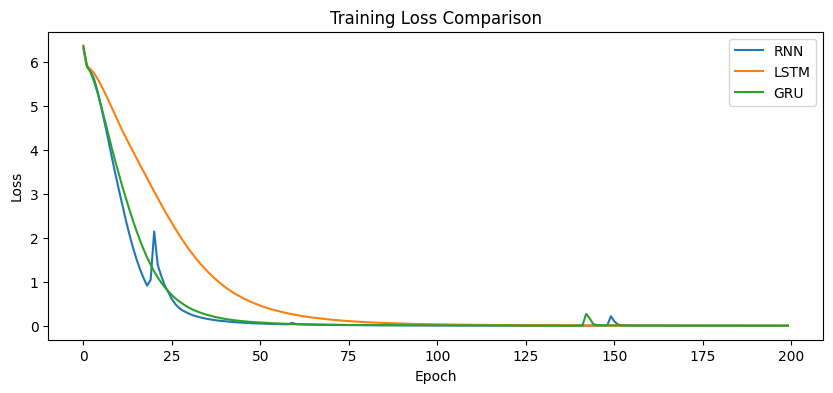

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [ ]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [ ]:
print(generate_text(rnn_model, "the probe", 10))
print(generate_text(lstm_model, "the sun", 10))
print(generate_text(gru_model, "the cornal", 10))

the probe of the solar wind a constant flow of material escaping
the sun is a historic moment in humanity’s first mission to a
the cornal biggest x class flares are by far the largest explosions


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**